In [2]:
pip install -q yfinance pandas numpy requests pyarrow

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import requests
import yfinance as yf
from io import StringIO

# Fechas del proyecto
START_DATE = "2005-01-01"
END_DATE   = "2026-03-25"

# Tu API key de FRED
FRED_API_KEY = "d204538af65fccda3b6dbdc33153edf9"

In [5]:
market_tickers = {
    "SPY": "SPY",
    "SPX": "^GSPC",
    "NASDAQ": "^IXIC",
    "RUSSELL2000": "^RUT",
    "VIX": "^VIX",
    "VIX9D": "^VIX9D",
    "VIX3M": "^VIX3M",
    "VVIX": "^VVIX",
    "SKEW": "^SKEW"
}

raw = yf.download(
    tickers=list(market_tickers.values()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False,
    group_by="ticker",
    threads=True
)

raw.head()

Ticker     ^VIX3M                                   ^VIX                       \
Price        Open High Low Close Adj Close Volume   Open   High    Low  Close   
Date                                                                            
2005-01-03    NaN  NaN NaN   NaN       NaN    NaN  13.39  14.23  13.25  14.08   
2005-01-04    NaN  NaN NaN   NaN       NaN    NaN  14.01  14.45  13.93  13.98   
2005-01-05    NaN  NaN NaN   NaN       NaN    NaN  13.98  14.09  13.26  14.09   
2005-01-06    NaN  NaN NaN   NaN       NaN    NaN  14.09  14.09  13.33  13.58   
2005-01-07    NaN  NaN NaN   NaN       NaN    NaN  13.47  13.51  12.94  13.49   

Ticker      ...        ^IXIC                                        \
Price       ...          Low        Close    Adj Close      Volume   
Date        ...                                                      
2005-01-03  ...  2148.719971  2152.149902  2152.149902  2193130000   
2005-01-04  ...  2100.560059  2107.860107  2107.860107  2690460000   
2005-01-05  ...  2091.239990  2091.239990  2091.239990  2375380000   
2005-01-06  ...  2088.030029  2090.000000  2090.000000  2174220000   
2005-01-07  ...  2076.689941  2088.610107  2088.610107  2191910000   

Ticker             SPY                                                 \
Price             Open        High         Low       Close  Adj Close   
Date                                                                    
2005-01-03  121.559998  121.760002  119.900002  120.300003  81.383728   
2005-01-04  120.459999  120.540001  118.440002  118.830002  80.389282   
2005-01-05  118.739998  119.250000  118.000000  118.010002  79.834534   
2005-01-06  118.440002  119.150002  118.260002  118.610001  80.240417   
2005-01-07  118.970001  119.230003  118.129997  118.440002  80.125420   

Ticker                
Price         Volume  
Date                  
2005-01-03  55748000  
2005-01-04  69167600  
2005-01-05  65667300  
2005-01-06  47814700  
2005-01-07  55847700  

[5 rows x 54 columns]

In [6]:
print(type(raw.columns))
print(raw.columns)

<class 'pandas.core.indexes.multi.MultiIndex'>
MultiIndex([('^VIX3M',      'Open'),
            ('^VIX3M',      'High'),
            ('^VIX3M',       'Low'),
            ('^VIX3M',     'Close'),
            ('^VIX3M', 'Adj Close'),
            ('^VIX3M',    'Volume'),
            (  '^VIX',      'Open'),
            (  '^VIX',      'High'),
            (  '^VIX',       'Low'),
            (  '^VIX',     'Close'),
            (  '^VIX', 'Adj Close'),
            (  '^VIX',    'Volume'),
            ('^VIX9D',      'Open'),
            ('^VIX9D',      'High'),
            ('^VIX9D',       'Low'),
            ('^VIX9D',     'Close'),
            ('^VIX9D', 'Adj Close'),
            ('^VIX9D',    'Volume'),
            ( '^VVIX',      'Open'),
            ( '^VVIX',      'High'),
            ( '^VVIX',       'Low'),
            ( '^VVIX',     'Close'),
            ( '^VVIX', 'Adj Close'),
            ( '^VVIX',    'Volume'),
            (  '^RUT',      'Open'),
            (  '^RUT',      

In [7]:
def flatten_yfinance_download(raw_df, ticker_map):
    frames = []

    available_tickers = raw_df.columns.get_level_values(0).unique()

    for name, ticker in ticker_map.items():
        if ticker not in available_tickers:
            print(f"No encontrado en descarga: {ticker}")
            continue

        temp = raw_df[ticker].copy()
        temp.columns = [f"{name}_{col.lower().replace(' ', '_')}" for col in temp.columns]
        frames.append(temp)

    df = pd.concat(frames, axis=1).sort_index()
    df.index = pd.to_datetime(df.index)
    return df

market_df = flatten_yfinance_download(raw, market_tickers)

print("Shape:", market_df.shape)
display(market_df.head())

Shape: (5339, 54)


,SPY_open,SPY_high,SPY_low,SPY_close,SPY_adj_close,SPY_volume,SPX_open,SPX_high,SPX_low,SPX_close,...,VVIX_low,VVIX_close,VVIX_adj_close,VVIX_volume,SKEW_open,SKEW_high,SKEW_low,SKEW_close,SKEW_adj_close,SKEW_volume
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,121.559998,121.760002,119.900002,120.300003,81.383728,55748000,1211.920044,1217.800049,1200.319946,1202.079956,...,NaN,NaN,NaN,NaN,118.379997,118.379997,118.379997,118.379997,118.379997,0.0
2005-01-04,120.459999,120.540001,118.440002,118.830002,80.389282,69167600,1202.079956,1205.839966,1185.390015,1188.050049,...,NaN,NaN,NaN,NaN,116.029999,116.029999,116.029999,116.029999,116.029999,0.0
2005-01-05,118.739998,119.250000,118.000000,118.010002,79.834534,65667300,1188.050049,1192.729980,1183.719971,1183.739990,...,NaN,NaN,NaN,NaN,114.720001,114.720001,114.720001,114.720001,114.720001,0.0
2005-01-06,118.440002,119.150002,118.260002,118.610001,80.240417,47814700,1183.739990,1191.630005,1183.270020,1187.890015,...,NaN,NaN,NaN,NaN,114.150002,114.150002,114.150002,114.150002,114.150002,0.0
2005-01-07,118.970001,119.230003,118.129997,118.440002,80.125420,55847700,1187.890015,1192.199951,1182.160034,1186.189941,...,NaN,NaN,NaN,NaN,114.949997,114.949997,114.949997,114.949997,114.949997,0.0


In [8]:
# Porcentaje de nulos por columna
na_pct = (market_df.isna().mean() * 100).sort_values(ascending=False)

print("Columnas con nulos:")
display(na_pct[na_pct > 0].round(2))

print("\nNúmero total de columnas:", market_df.shape[1])
print("Número total de filas:", market_df.shape[0])

Columnas con nulos:


VIX9D_open         28.30
VIX9D_high         28.30
VIX9D_low          28.30
VIX9D_close        28.30
VIX9D_adj_close    28.30
VIX9D_volume       28.30
VVIX_close          9.59
VVIX_volume         9.59
VVIX_adj_close      9.59
VVIX_low            9.59
VVIX_high           9.59
VVIX_open           9.59
VIX3M_close         7.23
VIX3M_low           7.23
VIX3M_volume        7.23
VIX3M_adj_close     7.23
VIX3M_open          7.23
VIX3M_high          7.23
SKEW_volume         1.18
SKEW_open           1.18
SKEW_high           1.18
SKEW_low            1.18
SKEW_close          1.18
SKEW_adj_close      1.18
dtype: float64


Número total de columnas: 54
Número total de filas: 5339


In [12]:
close_cols = [c for c in market_df.columns if c.endswith("_close") and not c.endswith("_adj_close")]
market_close = market_df[close_cols].copy()

print("Shape market_close:", market_close.shape)
print("\nColumnas:")
print(market_close.columns.tolist())

display(market_close.head())

Shape market_close: (5339, 9)

Columnas:
['SPY_close', 'SPX_close', 'NASDAQ_close', 'RUSSELL2000_close', 'VIX_close', 'VIX9D_close', 'VIX3M_close', 'VVIX_close', 'SKEW_close']


,SPY_close,SPX_close,NASDAQ_close,RUSSELL2000_close,VIX_close,VIX9D_close,VIX3M_close,VVIX_close,SKEW_close
Date,,,,,,,,,
2005-01-03,120.300003,1202.079956,2152.149902,640.440002,14.08,NaN,NaN,NaN,118.379997
2005-01-04,118.830002,1188.050049,2107.860107,628.539978,13.98,NaN,NaN,NaN,116.029999
2005-01-05,118.010002,1183.739990,2091.239990,617.479980,14.09,NaN,NaN,NaN,114.720001
2005-01-06,118.610001,1187.890015,2090.000000,619.820007,13.58,NaN,NaN,NaN,114.150002
2005-01-07,118.440002,1186.189941,2088.610107,613.210022,13.49,NaN,NaN,NaN,114.949997


In [13]:
na_close_pct = (market_close.isna().mean() * 100).sort_values(ascending=False)
display(na_close_pct.round(2))

VIX9D_close          28.30
VVIX_close            9.59
VIX3M_close           7.23
SKEW_close            1.18
SPY_close             0.00
SPX_close             0.00
NASDAQ_close          0.00
RUSSELL2000_close     0.00
VIX_close             0.00
dtype: float64

In [14]:
returns_df = pd.DataFrame(index=market_close.index)

for col in market_close.columns:
    base_name = col.replace("_close", "")
    returns_df[f"{base_name}_ret"] = market_close[col].pct_change()
    returns_df[f"{base_name}_logret"] = np.log(market_close[col] / market_close[col].shift(1))

print("Shape returns_df:", returns_df.shape)
display(returns_df.head(10))

Shape returns_df: (5339, 18)


/var/folders/wc/qvhbwxv54jg7chvxmc4536v80000gn/T/ipykernel_1706/63715558.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df[f"{base_name}_ret"] = market_close[col].pct_change()
/var/folders/wc/qvhbwxv54jg7chvxmc4536v80000gn/T/ipykernel_1706/63715558.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df[f"{base_name}_ret"] = market_close[col].pct_change()


,SPY_ret,SPY_logret,SPX_ret,SPX_logret,NASDAQ_ret,NASDAQ_logret,RUSSELL2000_ret,RUSSELL2000_logret,VIX_ret,VIX_logret,VIX9D_ret,VIX9D_logret,VIX3M_ret,VIX3M_logret,VVIX_ret,VVIX_logret,SKEW_ret,SKEW_logret
Date,,,,,,,,,,,,,,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,-0.012219,-0.012295,-0.011671,-0.011740,-0.020579,-0.020794,-0.018581,-0.018756,-0.007102,-0.007128,NaN,NaN,NaN,NaN,NaN,NaN,-0.019851,-0.020051
2005-01-05,-0.006901,-0.006925,-0.003628,-0.003634,-0.007885,-0.007916,-0.017596,-0.017753,0.007868,0.007838,NaN,NaN,NaN,NaN,NaN,NaN,-0.011290,-0.011354
2005-01-06,0.005084,0.005071,0.003506,0.003500,-0.000593,-0.000593,0.003790,0.003782,-0.036196,-0.036867,NaN,NaN,NaN,NaN,NaN,NaN,-0.004969,-0.004981
2005-01-07,-0.001433,-0.001434,-0.001431,-0.001432,-0.000665,-0.000665,-0.010664,-0.010722,-0.006627,-0.006649,NaN,NaN,NaN,NaN,NaN,NaN,0.007008,0.006984
2005-01-10,0.004728,0.004717,0.003423,0.003417,0.004036,0.004028,0.007387,0.007360,-0.019274,-0.019462,NaN,NaN,NaN,NaN,NaN,NaN,0.017138,0.016993
2005-01-11,-0.006891,-0.006915,-0.006100,-0.006118,-0.008307,-0.008342,-0.010053,-0.010104,-0.003023,-0.003028,NaN,NaN,NaN,NaN,NaN,NaN,-0.013941,-0.014039
2005-01-12,0.003300,0.003295,0.003981,0.003973,0.006208,0.006189,0.002714,0.002711,-0.047763,-0.048942,NaN,NaN,NaN,NaN,NaN,NaN,-0.038165,-0.038912
2005-01-13,-0.008012,-0.008044,-0.008630,-0.008668,-0.010499,-0.010555,-0.004990,-0.005003,0.022293,0.022048,NaN,NaN,NaN,NaN,NaN,NaN,0.015150,0.015037


In [15]:
na_returns_pct = (returns_df.isna().mean() * 100).sort_values(ascending=False)
display(na_returns_pct[na_returns_pct > 0].round(2))

VIX9D_logret          28.32
VIX9D_ret             28.32
VVIX_logret            9.78
VVIX_ret               9.44
VIX3M_logret           7.25
VIX3M_ret              7.25
SKEW_logret            2.27
SPY_logret             0.02
SKEW_ret               0.02
SPY_ret                0.02
VIX_ret                0.02
RUSSELL2000_logret     0.02
RUSSELL2000_ret        0.02
NASDAQ_logret          0.02
NASDAQ_ret             0.02
SPX_logret             0.02
SPX_ret                0.02
VIX_logret             0.02
dtype: float64

In [16]:
target_df = pd.DataFrame(index=returns_df.index)

# Log-retorno del SPY
spy_logret = returns_df["SPY_logret"]

# Volatilidad futura a 5 días:
# usamos shift(-1) para que empiece en el día siguiente, no incluyendo hoy
target_df["target_vol_5d"] = spy_logret.shift(-1).rolling(window=5).std()

# Versión anualizada opcional
target_df["target_vol_5d_annualized"] = target_df["target_vol_5d"] * np.sqrt(252)

print("Shape target_df:", target_df.shape)
display(target_df.head(10))
display(target_df.tail(10))

Shape target_df: (5339, 2)


,target_vol_5d,target_vol_5d_annualized
Date,,
2005-01-03,NaN,NaN
2005-01-04,NaN,NaN
2005-01-05,NaN,NaN
2005-01-06,NaN,NaN
2005-01-07,0.007509,0.119198
2005-01-10,0.005911,0.093838
2005-01-11,0.005104,0.081026
2005-01-12,0.005780,0.091755
2005-01-13,0.006571,0.104307


,target_vol_5d,target_vol_5d_annualized
Date,,
2026-03-11,0.009823,0.155932
2026-03-12,0.008673,0.137675
2026-03-13,0.009157,0.145365
2026-03-16,0.009479,0.150469
2026-03-17,0.010886,0.172803
2026-03-18,0.009047,0.143609
2026-03-19,0.011402,0.181002
2026-03-20,0.011503,0.182602
2026-03-23,0.010921,0.173372


In [17]:
print(target_df.isna().mean() * 100)
print("\nPrimer valor válido:")
print(target_df["target_vol_5d"].first_valid_index())

print("\nÚltimo valor válido:")
print(target_df["target_vol_5d"].last_valid_index())

target_vol_5d               0.09365
target_vol_5d_annualized    0.09365
dtype: float64

Primer valor válido:
2005-01-07 00:00:00

Último valor válido:
2026-03-23 00:00:00


<Axes: title={'center': 'Target: volatilidad futura a 5 días del SPY'}, xlabel='Date'>

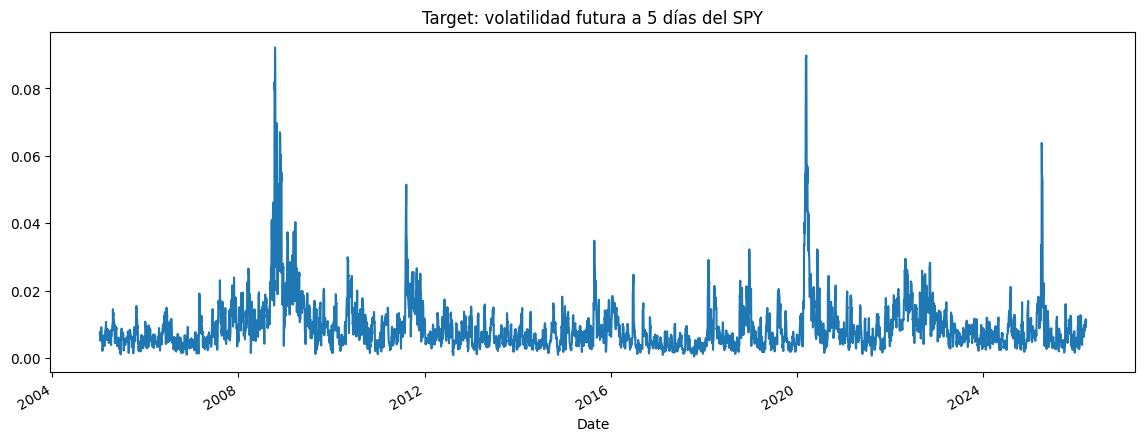

In [18]:
target_df["target_vol_5d"].plot(figsize=(14,5), title="Target: volatilidad futura a 5 días del SPY")

In [19]:
model_df = pd.concat([market_close, returns_df, target_df], axis=1).sort_index()

print("Shape model_df:", model_df.shape)
display(model_df.head())
display(model_df.tail())

Shape model_df: (5339, 29)


,SPY_close,SPX_close,NASDAQ_close,RUSSELL2000_close,VIX_close,VIX9D_close,VIX3M_close,VVIX_close,SKEW_close,SPY_ret,...,VIX9D_ret,VIX9D_logret,VIX3M_ret,VIX3M_logret,VVIX_ret,VVIX_logret,SKEW_ret,SKEW_logret,target_vol_5d,target_vol_5d_annualized
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,120.300003,1202.079956,2152.149902,640.440002,14.08,NaN,NaN,NaN,118.379997,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,118.830002,1188.050049,2107.860107,628.539978,13.98,NaN,NaN,NaN,116.029999,-0.012219,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.019851,-0.020051,NaN,NaN
2005-01-05,118.010002,1183.739990,2091.239990,617.479980,14.09,NaN,NaN,NaN,114.720001,-0.006901,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.011290,-0.011354,NaN,NaN
2005-01-06,118.610001,1187.890015,2090.000000,619.820007,13.58,NaN,NaN,NaN,114.150002,0.005084,...,NaN,NaN,NaN,NaN,NaN,NaN,-0.004969,-0.004981,NaN,NaN
2005-01-07,118.440002,1186.189941,2088.610107,613.210022,13.49,NaN,NaN,NaN,114.949997,-0.001433,...,NaN,NaN,NaN,NaN,NaN,NaN,0.007008,0.006984,0.007509,0.119198


,SPY_close,SPX_close,NASDAQ_close,RUSSELL2000_close,VIX_close,VIX9D_close,VIX3M_close,VVIX_close,SKEW_close,SPY_ret,...,VIX9D_ret,VIX9D_logret,VIX3M_ret,VIX3M_logret,VVIX_ret,VVIX_logret,SKEW_ret,SKEW_logret,target_vol_5d,target_vol_5d_annualized
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-18,661.429993,6624.700195,22152.419922,2478.639893,25.090000,26.030001,26.559999,126.500000,136.539993,-0.013954,...,0.164132,0.151976,0.091656,0.087696,0.144279,0.134774,-0.058605,-0.060392,0.009047,0.143609
2026-03-19,659.799988,6606.490234,22090.689453,2494.709961,24.059999,24.090000,25.540001,118.089996,138.259995,-0.002464,...,-0.074529,-0.077453,-0.038404,-0.039160,-0.066482,-0.068795,0.012597,0.012518,0.011402,0.181002
2026-03-20,648.570007,6506.479980,21647.609375,2438.449951,26.780001,26.950001,27.430000,126.279999,139.119995,-0.017020,...,0.118721,0.112187,0.074002,0.071391,0.069354,0.067055,0.006220,0.006201,0.011503,0.182602
2026-03-23,655.380005,6581.000000,21946.759766,2494.229980,26.150000,27.760000,26.100000,122.820000,142.020004,0.010500,...,0.030056,0.029613,-0.048487,-0.049702,-0.027399,-0.027782,0.020845,0.020631,0.010921,0.173372
2026-03-24,653.179993,6556.370117,21761.890625,2505.439941,26.950001,28.209999,26.559999,124.139999,142.630005,-0.003357,...,0.016210,0.016080,0.017624,0.017471,0.010747,0.010690,0.004295,0.004286,NaN,NaN


In [20]:
feat_df = model_df.copy()

# =========
# 1) Lags de retornos del SPY
# =========
for lag in [1, 2, 3, 5, 10, 21]:
    feat_df[f"SPY_logret_lag_{lag}"] = feat_df["SPY_logret"].shift(lag)

# =========
# 2) Volatilidad histórica pasada del SPY
# =========
for window in [5, 10, 21, 42]:
    feat_df[f"SPY_vol_past_{window}d"] = feat_df["SPY_logret"].rolling(window).std()

# =========
# 3) Retorno acumulado pasado del SPY
# =========
for window in [5, 10, 21]:
    feat_df[f"SPY_cumret_{window}d"] = feat_df["SPY_logret"].rolling(window).sum()

# =========
# 4) Magnitud de caídas recientes
# =========
feat_df["SPY_negative_logret"] = feat_df["SPY_logret"].clip(upper=0)
for window in [5, 10, 21]:
    feat_df[f"SPY_downside_vol_{window}d"] = feat_df["SPY_negative_logret"].rolling(window).std()

# =========
# 5) Lags de volatilidad implícita
# =========
for col in ["VIX_close", "VIX9D_close", "VIX3M_close", "VVIX_close", "SKEW_close"]:
    if col in feat_df.columns:
        for lag in [1, 2, 5]:
            feat_df[f"{col}_lag_{lag}"] = feat_df[col].shift(lag)

# =========
# 6) Ratios útiles de term structure
# =========
if "VIX9D_close" in feat_df.columns and "VIX_close" in feat_df.columns:
    feat_df["ratio_VIX9D_VIX"] = feat_df["VIX9D_close"] / feat_df["VIX_close"]

if "VIX_close" in feat_df.columns and "VIX3M_close" in feat_df.columns:
    feat_df["ratio_VIX_VIX3M"] = feat_df["VIX_close"] / feat_df["VIX3M_close"]

if "VVIX_close" in feat_df.columns and "VIX_close" in feat_df.columns:
    feat_df["ratio_VVIX_VIX"] = feat_df["VVIX_close"] / feat_df["VIX_close"]

# =========
# 7) Retornos de otros índices
# =========
for base in ["SPX", "NASDAQ", "RUSSELL2000", "VIX"]:
    col = f"{base}_logret"
    if col in feat_df.columns:
        for lag in [1, 2, 5]:
            feat_df[f"{col}_lag_{lag}"] = feat_df[col].shift(lag)

print("Shape feat_df:", feat_df.shape)
display(feat_df.head(10))

Shape feat_df: (5339, 76)


,SPY_close,SPX_close,NASDAQ_close,RUSSELL2000_close,VIX_close,VIX9D_close,VIX3M_close,VVIX_close,SKEW_close,SPY_ret,...,SPX_logret_lag_5,NASDAQ_logret_lag_1,NASDAQ_logret_lag_2,NASDAQ_logret_lag_5,RUSSELL2000_logret_lag_1,RUSSELL2000_logret_lag_2,RUSSELL2000_logret_lag_5,VIX_logret_lag_1,VIX_logret_lag_2,VIX_logret_lag_5
Date,,,,,,,,,,,,,,,,,,,,,
2005-01-03,120.300003,1202.079956,2152.149902,640.440002,14.08,NaN,NaN,NaN,118.379997,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,118.830002,1188.050049,2107.860107,628.539978,13.98,NaN,NaN,NaN,116.029999,-0.012219,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-05,118.010002,1183.739990,2091.239990,617.479980,14.09,NaN,NaN,NaN,114.720001,-0.006901,...,NaN,-0.020794,NaN,NaN,-0.018756,NaN,NaN,-0.007128,NaN,NaN
2005-01-06,118.610001,1187.890015,2090.000000,619.820007,13.58,NaN,NaN,NaN,114.150002,0.005084,...,NaN,-0.007916,-0.020794,NaN,-0.017753,-0.018756,NaN,0.007838,-0.007128,NaN
2005-01-07,118.440002,1186.189941,2088.610107,613.210022,13.49,NaN,NaN,NaN,114.949997,-0.001433,...,NaN,-0.000593,-0.007916,NaN,0.003782,-0.017753,NaN,-0.036867,0.007838,NaN
2005-01-10,119.000000,1190.250000,2097.040039,617.739990,13.23,NaN,NaN,NaN,116.919998,0.004728,...,NaN,-0.000665,-0.000593,NaN,-0.010722,0.003782,NaN,-0.006649,-0.036867,NaN
2005-01-11,118.180000,1182.989990,2079.620117,611.530029,13.19,NaN,NaN,NaN,115.290001,-0.006891,...,-0.011740,0.004028,-0.000665,-0.020794,0.007360,-0.010722,-0.018756,-0.019462,-0.006649,-0.007128
2005-01-12,118.570000,1187.699951,2092.530029,613.190002,12.56,NaN,NaN,NaN,110.889999,0.003300,...,-0.003634,-0.008342,0.004028,-0.007916,-0.010104,0.007360,-0.017753,-0.003028,-0.019462,0.007838
2005-01-13,117.620003,1177.449951,2070.560059,610.130005,12.84,NaN,NaN,NaN,112.570000,-0.008012,...,0.003500,0.006189,-0.008342,-0.000593,0.002711,-0.010104,0.003782,-0.048942,-0.003028,-0.036867


In [21]:
model_data = feat_df.copy()

# Quitamos filas sin target
model_data = model_data.dropna(subset=["target_vol_5d"])

print("Antes de limpiar features:", model_data.shape)

# Opción 1: eliminar cualquier fila con NaN
model_data_dropna = model_data.dropna().copy()

print("Después de dropna total:", model_data_dropna.shape)
display(model_data_dropna.head())

Antes de limpiar features: (5334, 76)
Después de dropna total: (3567, 76)


,SPY_close,SPX_close,NASDAQ_close,RUSSELL2000_close,VIX_close,VIX9D_close,VIX3M_close,VVIX_close,SKEW_close,SPY_ret,...,SPX_logret_lag_5,NASDAQ_logret_lag_1,NASDAQ_logret_lag_2,NASDAQ_logret_lag_5,RUSSELL2000_logret_lag_1,RUSSELL2000_logret_lag_2,RUSSELL2000_logret_lag_5,VIX_logret_lag_1,VIX_logret_lag_2,VIX_logret_lag_5
Date,,,,,,,,,,,,,,,,,,,,,
2011-01-10,126.980003,1269.750000,2707.800049,791.580017,17.540001,15.81,20.480000,81.650002,121.470001,-0.001258,...,0.011251,-0.002483,0.002842,0.014464,-0.004546,-0.004627,0.018848,-0.015055,0.022081,-0.007919
2011-01-11,127.430000,1274.479980,2716.830078,794.760010,16.889999,14.93,20.139999,79.820000,122.290001,0.003544,...,-0.001314,0.001711,-0.002483,-0.003823,0.004749,-0.004546,-0.016070,0.023069,-0.015055,-0.013147
2011-01-12,128.580002,1285.959961,2737.330078,801.359985,16.240000,14.82,19.230000,77.940002,121.940002,0.009025,...,0.004995,0.003329,0.001711,0.007783,0.004009,0.004749,0.011715,-0.037762,0.023069,-0.020931
2011-01-13,128.369995,1283.760010,2735.290039,800.650024,16.389999,14.92,19.200001,78.639999,121.290001,-0.001633,...,-0.002125,0.007517,0.003329,0.002842,0.008270,0.004009,-0.004627,-0.039244,-0.037762,0.022081
2011-01-14,129.300003,1293.239990,2755.300049,807.570007,15.460000,14.30,18.370001,75.940002,123.519997,0.007245,...,-0.001846,-0.000746,0.007517,-0.002483,-0.000886,0.008270,-0.004546,0.009194,-0.039244,-0.015055


In [22]:
print("Filas con target válido:", len(model_data))
print("Filas tras dropna total:", len(model_data_dropna))
print("Porcentaje conservado:", round(100 * len(model_data_dropna) / len(model_data), 2), "%")

Filas con target válido: 5334
Filas tras dropna total: 3567
Porcentaje conservado: 66.87 %


In [23]:
# Variables que NO queremos en la versión CORE
drop_patterns_core = [
    "VIX9D",
    "VIX3M",
    "VVIX",
    "ratio_VIX9D_VIX",
    "ratio_VIX_VIX3M",
    "ratio_VVIX_VIX"
]

core_cols = [
    c for c in feat_df.columns
    if not any(pattern in c for pattern in drop_patterns_core)
]

model_data_core = feat_df[core_cols].copy()
model_data_core = model_data_core.dropna(subset=["target_vol_5d"])

print("Shape antes de dropna total (core):", model_data_core.shape)

model_data_core = model_data_core.dropna().copy()

print("Shape final model_data_core:", model_data_core.shape)
print("Porcentaje conservado sobre target válido:", round(100 * len(model_data_core) / len(model_data), 2), "%")

display(model_data_core.head())

Shape antes de dropna total (core): (5334, 55)
Shape final model_data_core: (5067, 55)
Porcentaje conservado sobre target válido: 94.99 %


,SPY_close,SPX_close,NASDAQ_close,RUSSELL2000_close,VIX_close,SKEW_close,SPY_ret,SPY_logret,SPX_ret,SPX_logret,...,SPX_logret_lag_5,NASDAQ_logret_lag_1,NASDAQ_logret_lag_2,NASDAQ_logret_lag_5,RUSSELL2000_logret_lag_1,RUSSELL2000_logret_lag_2,RUSSELL2000_logret_lag_5,VIX_logret_lag_1,VIX_logret_lag_2,VIX_logret_lag_5
Date,,,,,,,,,,,,,,,,,,,,,
2005-03-04,122.730003,1222.119995,2070.610107,644.950012,11.94,121.980003,0.012457,0.012380,0.009624,0.009578,...,0.009264,-0.004411,-0.001812,0.006655,0.001505,-0.001881,0.015762,0.033822,0.037494,-0.006938
2005-03-07,122.790001,1225.310059,2090.209961,643.859985,12.26,123.860001,0.000489,0.000489,0.002610,0.002607,...,-0.006435,0.005914,-0.004411,-0.006645,0.010380,0.001505,-0.005458,-0.079656,0.033822,0.050074
2005-03-08,122.330002,1219.430054,2073.550049,637.979980,12.40,127.250000,-0.003746,-0.003753,-0.004799,-0.004810,...,0.005642,0.009421,0.005914,0.009474,-0.001692,0.010380,0.007025,0.026448,-0.079656,-0.003317
2005-03-09,120.970001,1207.010010,2061.290039,631.080017,12.70,115.849998,-0.011117,-0.011180,-0.010185,-0.010237,...,-0.000273,-0.008002,0.009421,-0.001812,-0.009174,-0.001692,-0.001881,0.011354,0.026448,0.037494
2005-03-10,121.239998,1209.250000,2059.719971,626.940002,12.49,118.500000,0.002232,0.002229,0.001856,0.001854,...,0.000322,-0.005930,-0.008002,-0.004411,-0.010874,-0.009174,0.001505,0.023906,0.011354,0.033822


In [24]:
target_col = "target_vol_5d"

feature_cols_core = [c for c in model_data_core.columns if c != target_col and c != "target_vol_5d_annualized"]

X_core = model_data_core[feature_cols_core].copy()
y_core = model_data_core[target_col].copy()

print("X_core shape:", X_core.shape)
print("y_core shape:", y_core.shape)

print("\nNúmero de features:", len(feature_cols_core))
print("\nPrimeras features:")
print(feature_cols_core[:20])

X_core shape: (5067, 53)
y_core shape: (5067,)

Número de features: 53

Primeras features:
['SPY_close', 'SPX_close', 'NASDAQ_close', 'RUSSELL2000_close', 'VIX_close', 'SKEW_close', 'SPY_ret', 'SPY_logret', 'SPX_ret', 'SPX_logret', 'NASDAQ_ret', 'NASDAQ_logret', 'RUSSELL2000_ret', 'RUSSELL2000_logret', 'VIX_ret', 'VIX_logret', 'SKEW_ret', 'SKEW_logret', 'SPY_logret_lag_1', 'SPY_logret_lag_2']


In [25]:
split_idx = int(len(X_core) * 0.8)

X_train = X_core.iloc[:split_idx].copy()
X_test  = X_core.iloc[split_idx:].copy()

y_train = y_core.iloc[:split_idx].copy()
y_test  = y_core.iloc[split_idx:].copy()

print("Train size:", X_train.shape, y_train.shape)
print("Test size:", X_test.shape, y_test.shape)

print("\nTrain fechas:")
print(X_train.index.min(), "->", X_train.index.max())

print("\nTest fechas:")
print(X_test.index.min(), "->", X_test.index.max())

Train size: (4053, 53) (4053,)
Test size: (1014, 53) (1014,)

Train fechas:
2005-03-04 00:00:00 -> 2021-08-24 00:00:00

Test fechas:
2021-08-25 00:00:00 -> 2026-03-23 00:00:00


## Baseline 1 con regresión lineal

In [28]:
pip install scikit-learn lightgbm xgboost catboost --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

Linear Regression
MAE : 0.0017742005965960986
RMSE: 0.0027370076834634174
R2  : 0.795860687723251


/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,y_test,pred_lr
Date,,
2021-08-25,0.005911,0.003287
2021-08-26,0.006131,0.005040
2021-08-27,0.005386,0.005052
2021-08-30,0.005643,0.004917
2021-08-31,0.005652,0.004814


<Axes: title={'center': 'Volatilidad real vs predicha - Linear Regression'}, xlabel='Date'>

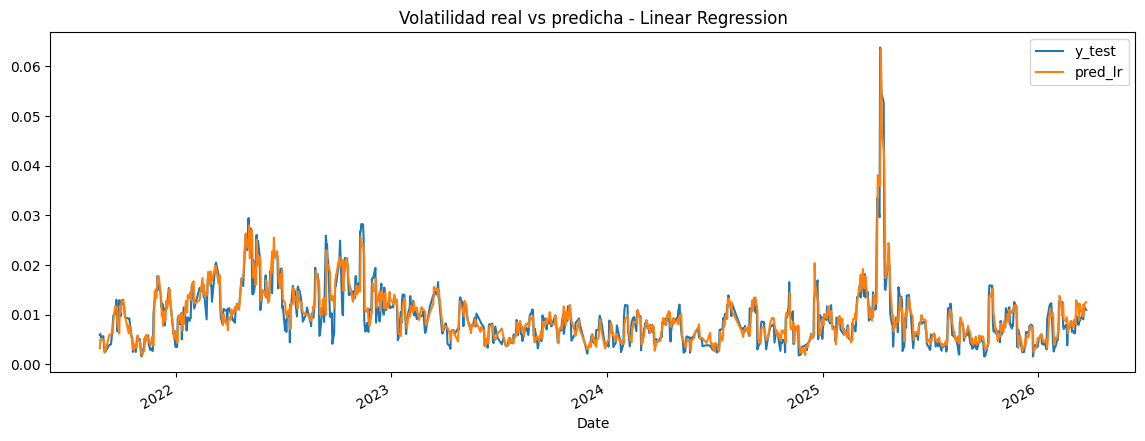

In [30]:
pred_df = pd.DataFrame({
    "y_test": y_test,
    "pred_lr": pred_lr
}, index=y_test.index)

display(pred_df.head())

pred_df[["y_test", "pred_lr"]].plot(figsize=(14,5), title="Volatilidad real vs predicha - Linear Regression")

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import numpy as np

In [32]:
def evaluate_regression(y_true, y_pred, model_name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    
    return {
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Corr": corr
    }

In [33]:
models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=1e-5, max_iter=20000))
    ]),
    
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )
}

In [34]:
results = []

# Baseline naive
naive_pred = X_test["SPY_vol_past_5d"].values

results.append(
    evaluate_regression(y_test.values, naive_pred, model_name="Naive_SPY_vol_past_5d")
)

results

[{'model': 'Naive_SPY_vol_past_5d',
  'MAE': 0.001656343648914924,
  'RMSE': np.float64(0.0029537545301020498),
  'R2': 0.762248417903561,
  'Corr': np.float64(0.8822617999937852)}]

In [35]:
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    predictions_dict[name] = preds
    results.append(evaluate_regression(y_test.values, preds, model_name=name))

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,model,MAE,RMSE,R2,Corr
0,RandomForest,0.001635,0.002704,0.800824,0.895094
1,Lasso,0.001733,0.002712,0.799639,0.894742
2,ExtraTrees,0.001628,0.002712,0.799510,0.894960
3,GradientBoosting,0.001619,0.002717,0.798851,0.894205
4,Ridge,0.001775,0.002735,0.796125,0.893944
5,LinearRegression,0.001774,0.002737,0.795861,0.894097
6,Naive_SPY_vol_past_5d,0.001656,0.002954,0.762248,0.882262


In [36]:
predictions_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    predictions_dict[name] = preds
    results.append(evaluate_regression(y_test.values, preds, model_name=name))

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,model,MAE,RMSE,R2,Corr
0,RandomForest,0.001635,0.002704,0.800824,0.895094
1,RandomForest,0.001635,0.002704,0.800824,0.895094
2,Lasso,0.001733,0.002712,0.799639,0.894742
3,Lasso,0.001733,0.002712,0.799639,0.894742
4,ExtraTrees,0.001628,0.002712,0.799510,0.894960
5,ExtraTrees,0.001628,0.002712,0.799510,0.894960
6,GradientBoosting,0.001619,0.002717,0.798851,0.894205
7,GradientBoosting,0.001619,0.002717,0.798851,0.894205
8,Ridge,0.001775,0.002735,0.796125,0.893944
9,Ridge,0.001775,0.002735,0.796125,0.893944


Mejor modelo por RMSE: RandomForest


<Axes: title={'center': 'Volatilidad real vs predicha - RandomForest'}, xlabel='Date'>

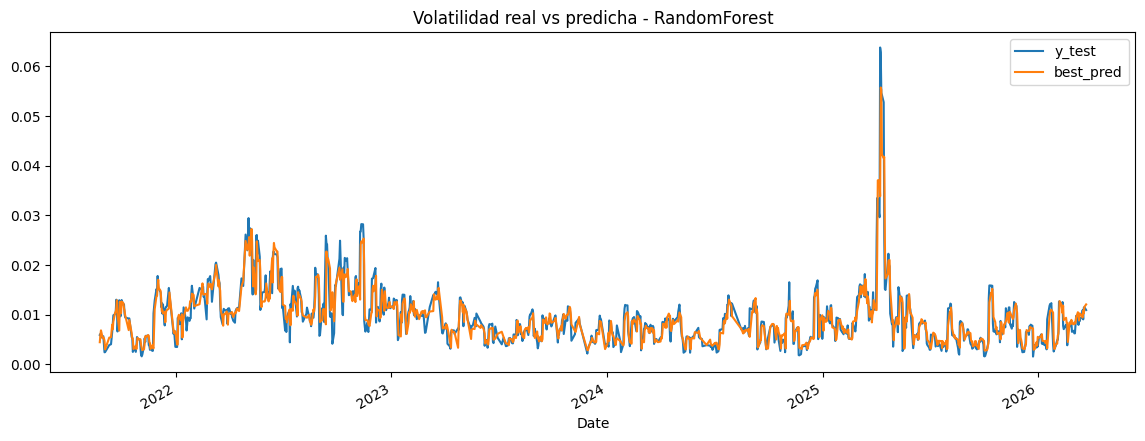

In [37]:
best_model_name = results_df.iloc[0]["model"]
print("Mejor modelo por RMSE:", best_model_name)

if best_model_name == "Naive_SPY_vol_past_5d":
    best_pred = naive_pred
else:
    best_pred = predictions_dict[best_model_name]

best_pred_df = pd.DataFrame({
    "y_test": y_test.values,
    "best_pred": best_pred
}, index=y_test.index)

best_pred_df[["y_test", "best_pred"]].plot(
    figsize=(14, 5),
    title=f"Volatilidad real vs predicha - {best_model_name}"
)

In [38]:
results = []
predictions_dict = {}

# Baseline naive
naive_pred = X_test["SPY_vol_past_5d"].values
results.append(
    evaluate_regression(y_test.values, naive_pred, model_name="Naive_SPY_vol_past_5d")
)

# Modelos
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions_dict[name] = preds
    results.append(evaluate_regression(y_test.values, preds, model_name=name))

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)

/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/quique/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,model,MAE,RMSE,R2,Corr
0,RandomForest,0.001635,0.002704,0.800824,0.895094
1,Lasso,0.001733,0.002712,0.799639,0.894742
2,ExtraTrees,0.001628,0.002712,0.799510,0.894960
3,GradientBoosting,0.001619,0.002717,0.798851,0.894205
4,Ridge,0.001775,0.002735,0.796125,0.893944
5,LinearRegression,0.001774,0.002737,0.795861,0.894097
6,Naive_SPY_vol_past_5d,0.001656,0.002954,0.762248,0.882262


In [39]:
rf_model = models["RandomForest"]
rf_model.fit(X_train, y_train)

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importances.head(20))

,feature,importance
0,SPY_vol_past_5d,0.755886
1,SPY_vol_past_10d,0.132660
2,SPY_downside_vol_10d,0.019402
3,VIX_close,0.019004
4,SPY_downside_vol_5d,0.007639
5,VIX_close_lag_1,0.007385
6,SPY_cumret_10d,0.006147
7,SPY_cumret_21d,0.005103
8,SPY_logret_lag_3,0.004837
9,VIX_close_lag_2,0.003293


<Axes: title={'center': 'Top 20 feature importances - RandomForest'}, ylabel='feature'>

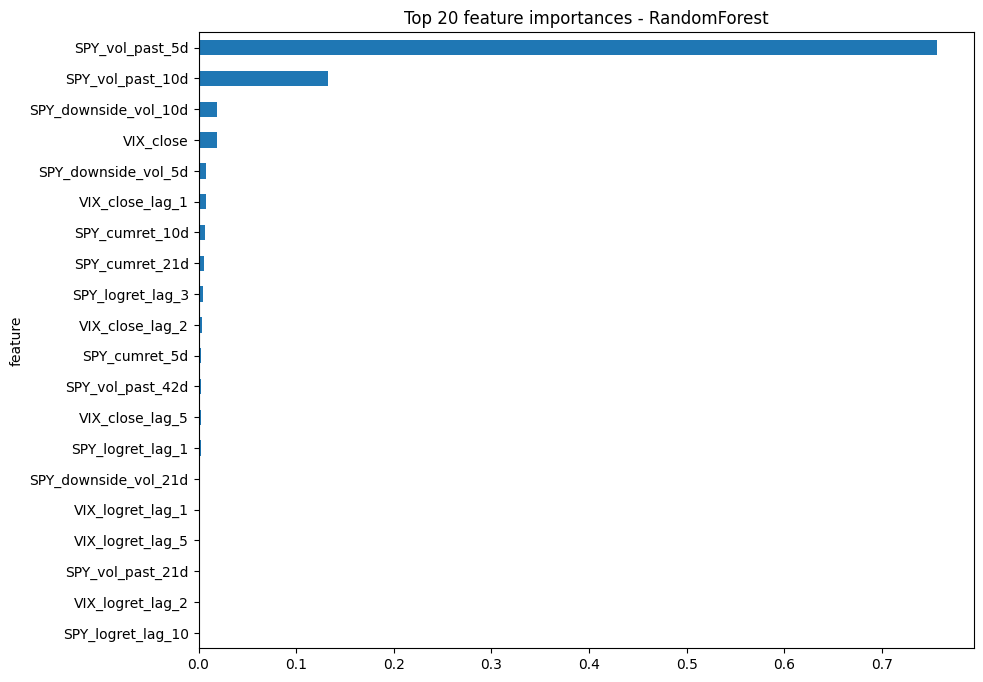

In [40]:
top_n = 20
imp_top = importances.head(top_n).sort_values("importance")

imp_top.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 8),
    title=f"Top {top_n} feature importances - RandomForest",
    legend=False
)

In [44]:
top10_features = importances.head(10)["feature"].tolist()
print("Top 10 features:")
print(top10_features)

X_train_top10 = X_train[top10_features].copy()
X_test_top10 = X_test[top10_features].copy()

rf_top10 = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_top10.fit(X_train_top10, y_train)
pred_rf_top10 = rf_top10.predict(X_test_top10)

print("Hecho.")
print("Shape X_train_top10:", X_train_top10.shape)
print("Shape X_test_top10 :", X_test_top10.shape)
print("Primeras predicciones:")
print(pred_rf_top10[:5])

Top 10 features:
['SPY_vol_past_5d', 'SPY_vol_past_10d', 'SPY_downside_vol_10d', 'VIX_close', 'SPY_downside_vol_5d', 'VIX_close_lag_1', 'SPY_cumret_10d', 'SPY_cumret_21d', 'SPY_logret_lag_3', 'VIX_close_lag_2']
Hecho.
Shape X_train_top10: (4053, 10)
Shape X_test_top10 : (1014, 10)
Primeras predicciones:
[0.00427176 0.00584838 0.00661494 0.00556481 0.00556886]


In [45]:
comparison_small = pd.DataFrame([
    {
        "model": "RandomForest_full",
        "MAE": mean_absolute_error(y_test, predictions_dict["RandomForest"]),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions_dict["RandomForest"])),
        "R2": r2_score(y_test, predictions_dict["RandomForest"]),
        "Corr": np.corrcoef(y_test, predictions_dict["RandomForest"])[0, 1]
    },
    {
        "model": "RandomForest_top10",
        "MAE": mean_absolute_error(y_test, pred_rf_top10),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_rf_top10)),
        "R2": r2_score(y_test, pred_rf_top10),
        "Corr": np.corrcoef(y_test, pred_rf_top10)[0, 1]
    }
]).sort_values("RMSE").reset_index(drop=True)

display(comparison_small)

,model,MAE,RMSE,R2,Corr
0,RandomForest_full,0.001635,0.002704,0.800824,0.895094
1,RandomForest_top10,0.001669,0.002760,0.792423,0.890477


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def eval_model(model, X_tr, y_tr, X_val, y_val, model_name="model", extra_info=None):
    model.fit(X_tr, y_tr)
    pred_val = model.predict(X_val)

    out = {
        "model": model_name,
        "MAE_val": mean_absolute_error(y_val, pred_val),
        "RMSE_val": np.sqrt(mean_squared_error(y_val, pred_val)),
        "R2_val": r2_score(y_val, pred_val),
        "Corr_val": np.corrcoef(y_val, pred_val)[0, 1]
    }

    if extra_info is not None:
        out.update(extra_info)

    return out